Sophia Senh

BSAN 360

December 12, 2025

Analyzing Seasonal Trends in Cat and Dog Adoptions

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('animalshelter.csv')

In [4]:
df

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
...,...,...,...,...,...,...,...,...,...,...,...,...
173770,A671565,2013-07-06,NaN,2014-02-07T10:14:00,02-2014,Transfer,SCRP,Cat,Spayed Female,7 months,Domestic Medium Hair Mix,Brown Tabby
173771,A675119,2014-02-16,NaN,2014-03-27T08:00:00,03-2014,Transfer,Partner,Dog,Intact Male,1 month,Pomeranian Mix,White/Brown
173772,A677839,2014-01-29,NaN,2014-05-03T08:00:00,05-2014,Transfer,Partner,Other,Unknown,3 months,Lop-English Mix,Chocolate
173773,A678559,2011-05-10,Gatsby,2014-05-14T08:00:00,05-2014,Transfer,Partner,Dog,Intact Male,3 years,Pekingese/Lhasa Apso,Buff


In [5]:
data_shape = df.shape

In [6]:
print(f"DataFrame shape: {data_shape[0]} rows, {data_shape[1]} columns")

DataFrame shape: 173775 rows, 12 columns


In [7]:
display(df.head())

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A668305,2012-12-01,NaN,2013-12-02T00:00:00-05:00,12-2013,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Brown/Yellow
1,A673335,2012-02-22,NaN,2014-02-22T00:00:00-05:00,02-2014,Euthanasia,Suffering,Other,Unknown,2 years,Raccoon,Black/Gray
2,A675999,2013-04-03,NaN,2014-04-07T00:00:00-05:00,04-2014,Transfer,Partner,Other,Unknown,1 year,Turtle Mix,Green
3,A679066,2014-04-16,NaN,2014-05-16T00:00:00-05:00,05-2014,NaN,NaN,Other,Unknown,4 weeks,Rabbit Sh,Brown
4,A680855,2014-05-25,NaN,2014-06-10T00:00:00-05:00,06-2014,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


In [8]:
display(df.tail())

,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
173770,A671565,2013-07-06,NaN,2014-02-07T10:14:00,02-2014,Transfer,SCRP,Cat,Spayed Female,7 months,Domestic Medium Hair Mix,Brown Tabby
173771,A675119,2014-02-16,NaN,2014-03-27T08:00:00,03-2014,Transfer,Partner,Dog,Intact Male,1 month,Pomeranian Mix,White/Brown
173772,A677839,2014-01-29,NaN,2014-05-03T08:00:00,05-2014,Transfer,Partner,Other,Unknown,3 months,Lop-English Mix,Chocolate
173773,A678559,2011-05-10,Gatsby,2014-05-14T08:00:00,05-2014,Transfer,Partner,Dog,Intact Male,3 years,Pekingese/Lhasa Apso,Buff
173774,A678592,2013-05-10,NaN,2014-05-14T08:00:00,05-2014,Transfer,Partner,Other,Unknown,1 year,Rabbit Sh Mix,Black


In [9]:
# question 4

In [10]:
print(df.columns)

Index(['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear',
       'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome',
       'Age upon Outcome', 'Breed', 'Color'],
      dtype='object')


In [11]:
new_column_map = {
    'Animal ID': 'animal_id',
    'Date of Birth': 'date_of_birth_str',
    'Name': 'name',
    'DateTime': 'datetime_str',
    'MonthYear': 'monthyear_str',
    'Outcome Type': 'outcome_type',
    'Outcome Subtype': 'outcome_subtype',
    'Animal Type': 'animal_type',
    'Sex upon Outcome': 'sex_upon_outcome',
    'Age upon Outcome': 'age_upon_outcome',
    'Breed': 'breed',
    'Color': 'color'
}


In [12]:
df = df.rename(columns=new_column_map)
print(df.columns)

Index(['animal_id', 'date_of_birth_str', 'name', 'datetime_str',
       'monthyear_str', 'outcome_type', 'outcome_subtype', 'animal_type',
       'sex_upon_outcome', 'age_upon_outcome', 'breed', 'color'],
      dtype='object')


In [13]:
from datetime import datetime, date, time

In [14]:
dob_list = []
datetime_list = []
monthyear_list = []

In [15]:
def parse_date_strptime(date_string, fmt):
    if not isinstance(date_string, str):
        return None
    return datetime.strptime(date_string, fmt)

In [16]:
for index in df.index:
    # Date of Birth
    dob_str = df.loc[index, 'date_of_birth_str']
    parsed_dob = parse_date_strptime(dob_str, '%Y-%m-%d')
    dob_list.append(parsed_dob)

    # DateTime
    datetime_str_val = df.loc[index, 'datetime_str']
    parsed_datetime = parse_date_strptime(datetime_str_val[:19] if isinstance(datetime_str_val, str) else None, '%Y-%m-%dT%H:%M:%S')
    datetime_list.append(parsed_datetime)

    # MonthYear
    monthyear_str_val = df.loc[index, 'monthyear_str']
    parsed_monthyear = parse_date_strptime(monthyear_str_val, '%m-%Y')
    monthyear_list.append(parsed_monthyear)

In [17]:
df['date_of_birth'] = dob_list
df['datetime'] = datetime_list
df['monthyear'] = monthyear_list

In [18]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])

In [19]:
df['age_in_days'] = (df['datetime'] - df['date_of_birth']).dt.days

In [20]:
print(df[['datetime', 'date_of_birth', 'age_in_days']].head())

    datetime date_of_birth  age_in_days
0 2013-12-02    2012-12-01          366
1 2014-02-22    2012-02-22          731
2 2014-04-07    2013-04-03          369
3 2014-05-16    2014-04-16           30
4 2014-06-10    2014-05-25           16


In [21]:
if 'date_of_birth_str' in df.columns:
    df = df.drop(columns=['date_of_birth_str'])
if 'datetime_str' in df.columns:
     df = df.drop(columns=['datetime_str'])
if 'monthyear_str' in df.columns:
     df = df.drop(columns=['monthyear_str'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173775 entries, 0 to 173774
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   animal_id         173775 non-null  object        
 1   name              123991 non-null  object        
 2   outcome_type      173729 non-null  object        
 3   outcome_subtype   79660 non-null   object        
 4   animal_type       173775 non-null  object        
 5   sex_upon_outcome  173774 non-null  object        
 6   age_upon_outcome  173766 non-null  object        
 7   breed             173775 non-null  object        
 8   color             173775 non-null  object        
 9   date_of_birth     173775 non-null  datetime64[ns]
 10  datetime          173775 non-null  datetime64[ns]
 11  monthyear         173775 non-null  datetime64[ns]
 12  age_in_days       173775 non-null  int64         
dtypes: datetime64[ns](3), int64(1), object(9)
memory usage: 17.

In [23]:
display(df.describe())

,date_of_birth,datetime,monthyear,age_in_days
count,173775,173775,173775,173775.000000
mean,2016-10-27 03:06:01.025463808,2018-11-28 21:17:03.720379904,2018-11-13 10:47:23.331894784,762.145475
min,1991-09-22 00:00:00,2013-10-01 09:31:00,2013-10-01 00:00:00,-1548.000000
25%,2014-03-19 00:00:00,2016-02-12 18:45:47,2016-02-01 00:00:00,90.000000
50%,2016-11-12 00:00:00,2018-08-06 16:15:00,2018-08-01 00:00:00,369.000000
75%,2019-12-29 00:00:00,2021-08-23 17:59:00,2021-08-01 00:00:00,812.000000
max,2028-05-01 00:00:00,2025-05-05 07:22:00,2025-05-01 00:00:00,10996.000000
std,NaN,NaN,NaN,1042.924341


In [24]:
display(df.describe(include='all'))

,animal_id,name,outcome_type,outcome_subtype,animal_type,sex_upon_outcome,age_upon_outcome,breed,color,date_of_birth,datetime,monthyear,age_in_days
count,173775,123991,173729,79660,173775,173774,173766,173775,173775,173775,173775,173775,173775.000000
unique,156237,29756,11,26,5,5,55,3010,663,NaN,NaN,NaN,NaN
top,A721033,Luna,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White,NaN,NaN,NaN,NaN
freq,33,760,84598,40410,94505,60933,28782,34039,17999,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-10-27 03:06:01.025463808,2018-11-28 21:17:03.720379904,2018-11-13 10:47:23.331894784,762.145475
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1991-09-22 00:00:00,2013-10-01 09:31:00,2013-10-01 00:00:00,-1548.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-19 00:00:00,2016-02-12 18:45:47,2016-02-01 00:00:00,90.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-11-12 00:00:00,2018-08-06 16:15:00,2018-08-01 00:00:00,369.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-29 00:00:00,2021-08-23 17:59:00,2021-08-01 00:00:00,812.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2028-05-01 00:00:00,2025-05-05 07:22:00,2025-05-01 00:00:00,10996.000000


Project Question 1:
Question: Do dog adoption counts vary significantly across different seasons of the year?

    Columns Needed: 'outcome_type', 'animal_type', 'datetime'

    outcome_type is used to filter for 'Adoption' outcomes.

    animal_type is used to filter for 'Dog'.

    datetime contains the date information needed to determine the month of the outcome.

Project Question 2:
Question: Do cat adoption counts vary significantly across different seasons of the year?

    Columns Needed:'outcome_type', 'animal_type', 'datetime'

    outcome_type is used to filter for 'Adoption' outcomes.

    animal_type is used to filter for 'Cat'.

    datetime contains the date information needed to determine the month of the outcome.

In [25]:
all_needed_columns = [
    'outcome_type',
    'animal_type',
    'datetime'
]

In [26]:
project_df = df[(df['outcome_type'] == df['outcome_type']) & \
                (df['datetime'] == df['datetime']) & \
                (df['animal_type'] == df['animal_type'])][all_needed_columns].copy()

In [27]:
project_df.loc[:, 'outcome_month'] = project_df['datetime'].dt.month
project_df.loc[:, 'outcome_year'] = project_df['datetime'].dt.year

In [28]:
display(project_df.head())

,outcome_type,animal_type,datetime,outcome_month,outcome_year
0,Transfer,Other,2013-12-02,12,2013
1,Euthanasia,Other,2014-02-22,2,2014
2,Transfer,Other,2014-04-07,4,2014
4,Transfer,Bird,2014-06-10,6,2014
5,Transfer,Bird,2014-06-10,6,2014


In [29]:
project_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173729 entries, 0 to 173774
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   outcome_type   173729 non-null  object        
 1   animal_type    173729 non-null  object        
 2   datetime       173729 non-null  datetime64[ns]
 3   outcome_month  173729 non-null  int32         
 4   outcome_year   173729 non-null  int32         
dtypes: datetime64[ns](1), int32(2), object(2)
memory usage: 6.6+ MB


Questions: Do dog/cat adoption counts vary significantly across months?

Analysis Plan:

    1.  Filtering & Aggregation: Filter the data to include only 'Dog' or 'Cat' records with an 'Adoption' outcome_type. Then, group by the extracted outcome_month and count the number of adoptions for each month.
    2.  Visualization: Create bar charts or line plots showing the total adoption counts per month for both dogs and cats separately. This will help visually identify potential seasonal patterns.
    3.  Statistical Test: To determine if the observed monthly variations in adoption *counts* are statistically significant, a Chi-Squared Goodness-of-Fit test is appropriate. This test compares the observed distribution of adoptions across the 12 months to an expected distribution (example: assuming adoptions are equally likely in any month). This matches the goal of seeing if counts differ significantly among groups (months), which is similar in concept to the ANOVA example mentioned for comparing means, but adapted for count data.
    

Here, I grouped months into seasons to simplify my analysis.

In [30]:
month_map = {1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8, 9:9, 10:10, 11:11, 12:0}
project_df.loc[:, 'seasonal_month'] = project_df['outcome_month'].map(month_map)

In [31]:
bins = [-1, 2, 5, 8, 11]
season_labels = ['Winter', 'Spring', 'Summer', 'Fall']

In [32]:
project_df.loc[:, 'season'] = pd.cut(project_df['seasonal_month'], bins=bins, labels=season_labels, right=True)

In [33]:
display(project_df.head())

,outcome_type,animal_type,datetime,outcome_month,outcome_year,seasonal_month,season
0,Transfer,Other,2013-12-02,12,2013,0,Winter
1,Euthanasia,Other,2014-02-22,2,2014,2,Winter
2,Transfer,Other,2014-04-07,4,2014,4,Spring
4,Transfer,Bird,2014-06-10,6,2014,6,Summer
5,Transfer,Bird,2014-06-10,6,2014,6,Summer


Here, I filtered out other animals to only focus on cats and dogs.

In [34]:
is_cat = project_df['animal_type'] == 'Cat'
is_dog = project_df['animal_type'] == 'Dog'

In [35]:
is_adoption = project_df['outcome_type'] == 'Adoption'

In [36]:
project_df_filtered = project_df[ (is_cat | is_dog) & is_adoption ].copy()

In [37]:
project_df_transformed = pd.get_dummies(project_df_filtered, columns=['animal_type'])

Here I filtered out years that do not have "complete data" in the sense that they don't capture data for the whole year (example: starts halfway in a year or only includes beginning of the year), which can skew results since it doesn't represent every season in that year.

In [38]:
monthly_counts_per_year = project_df_transformed.groupby('outcome_year')['outcome_month'].nunique()

In [39]:
display(monthly_counts_per_year)

outcome_year
2013     3
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025     5
Name: outcome_month, dtype: int64

In [40]:
complete_years_bool = monthly_counts_per_year == 12

In [41]:
complete_years_list = monthly_counts_per_year[complete_years_bool].index

In [42]:
project_df_complete_years = project_df_transformed[
    project_df_transformed['outcome_year'].isin(complete_years_list)
].copy()

In [43]:
display(project_df_complete_years.head())

,outcome_type,datetime,outcome_month,outcome_year,seasonal_month,season,animal_type_Cat,animal_type_Dog
12,Adoption,2014-07-11,7,2014,7,Summer,False,True
42,Adoption,2015-03-11,3,2015,3,Spring,False,True
43,Adoption,2015-03-14,3,2015,3,Spring,False,True
62,Adoption,2015-04-02,4,2015,4,Spring,False,True
63,Adoption,2015-04-03,4,2015,4,Spring,False,True


Here, I dropped datetime, outcome_month, seasonal_month, and outcome_year because it is sorted by season instead. Then, i dropped outcome_type because I already filtered out other outcome types that aren't adoptions, so I know all the data left is about adopted cats and dogs.

In [44]:
final_project_df = project_df_complete_years.drop(columns=['datetime', 'outcome_month', 'seasonal_month','outcome_year','outcome_type'])

In [45]:
display(final_project_df.head())

,season,animal_type_Cat,animal_type_Dog
12,Summer,False,True
42,Spring,False,True
43,Spring,False,True
62,Spring,False,True
63,Spring,False,True


In [46]:
final_project_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79307 entries, 12 to 170182
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   season           79307 non-null  category
 1   animal_type_Cat  79307 non-null  bool    
 2   animal_type_Dog  79307 non-null  bool    
dtypes: bool(2), category(1)
memory usage: 852.1 KB


Processing Strings:

In [47]:
df_strings = final_project_df.copy()

In [48]:
df_strings['season'] = df_strings['season'].astype(str)

In [49]:
df_strings['season'] = df_strings['season'].str.strip()

In [50]:
df_strings['season'] = df_strings['season'].str.title()

In [51]:
print(df_strings['season'].unique())

['Summer' 'Spring' 'Fall' 'Winter']


For this section, I cleaned and standardized the text data in the season column by removing white space, fixing the capitalization, and correcting any typos. 

Data Wrangling: Combining and Merging Datasets

For this section, I did not end up needing to combine or merge data sets as I am only using one file for my project. Therefore, I had decided to omit this section for this project.

Data Wrangling: Reshaping and Pivoting

In [52]:
pivot = (
    final_project_df
    .groupby('season')[['animal_type_Cat', 'animal_type_Dog']]
    .sum()
    .reset_index()
)

display(pivot)

,season,animal_type_Cat,animal_type_Dog
0,Winter,7189,11923
1,Spring,4793,10931
2,Summer,12528,11929
3,Fall,9552,10462


In [53]:
melted = pivot.melt(
    id_vars='season',
    var_name='animal_type',
    value_name='adoptions'
)

display(melted)

,season,animal_type,adoptions
0,Winter,animal_type_Cat,7189
1,Spring,animal_type_Cat,4793
2,Summer,animal_type_Cat,12528
3,Fall,animal_type_Cat,9552
4,Winter,animal_type_Dog,11923
5,Spring,animal_type_Dog,10931
6,Summer,animal_type_Dog,11929
7,Fall,animal_type_Dog,10462


In [54]:
reshaped = melted.pivot(
    index='season',
    columns='animal_type',
    values='adoptions'
).reset_index()

display(reshaped)

animal_type,season,animal_type_Cat,animal_type_Dog
0,Winter,7189,11923
1,Spring,4793,10931
2,Summer,12528,11929
3,Fall,9552,10462


For this section I reshaped my data to be able to analyze adoption counts by season (Spring, Summer, Fall, Winter) and animal type (Dog, Cat).

To do this, I first started by using groupby and sum to create a pivot-style summary table to show how many cats and dogs were adopted each season.

Then I melted and pivoted the data to show different forms of the same data and how it can be represented for a different kind of analysis

Here, I will create a bar plot using Seaborn
x='season' will be our categories on the bottom
y='adoptions' will be the height of the bars
hue='animal_type' will create separate bars for cats and dogs.
this graph will let me see if there is a visual pattern to be identified in seasonal adoption rates between cats and dogs.


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

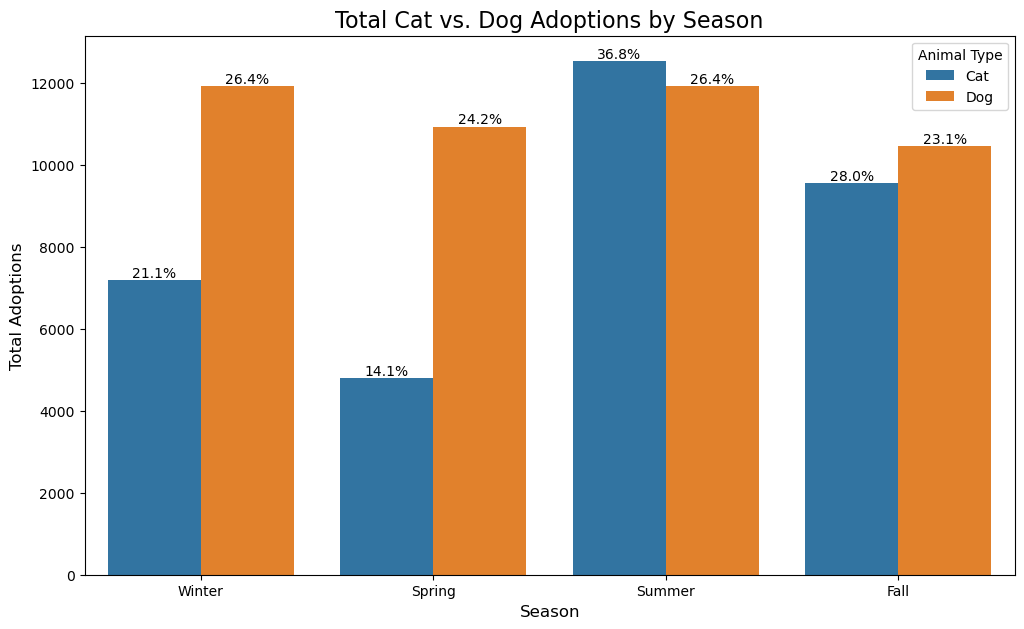

In [56]:
plt.figure(figsize=(12, 7))


ax = sns.barplot(
    data=melted,
    x='season',
    y='adoptions',
    hue='animal_type'
)
ax.set_title('Total Cat vs. Dog Adoptions by Season', fontsize=16)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Total Adoptions', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
new_labels = ['Cat', 'Dog']
ax.legend(handles=handles, labels=new_labels, title='Animal Type')

cat_total = melted[melted['animal_type'] == 'animal_type_Cat']['adoptions'].sum()
dog_total = melted[melted['animal_type'] == 'animal_type_Dog']['adoptions'].sum()
totals = [cat_total, dog_total] 

for i, container in enumerate(ax.containers):
    current_animal_total = totals[i]
    
    labels = [f'{h/current_animal_total*100:.1f}%' for h in container.datavalues]
    
    ax.bar_label(container, labels=labels)
    
plt.show()

For this section, I will be using data aggregation and grouping on the animal shelter dataset to summarize adoption patterns and then I will create pivot tables and cross-tabulations to show how categorical data such as animal type and season relate to adoption outcomes.

In [57]:
grouped = final_project_df.groupby('season')[['animal_type_Cat', 'animal_type_Dog']].sum().reset_index()
print(grouped)

   season  animal_type_Cat  animal_type_Dog
0  Winter             7189            11923
1  Spring             4793            10931
2  Summer            12528            11929
3    Fall             9552            10462


I grouped data by season to help identify and understand which seasons tend to have higher adoption activity overall

In [58]:
pivot_table = pd.pivot_table(
    final_project_df,
    values=['animal_type_Cat', 'animal_type_Dog'],
    index='season',
    aggfunc='sum',
    fill_value=0
)

display(pivot_table)

,animal_type_Cat,animal_type_Dog
season,,
Winter,7189,11923
Spring,4793,10931
Summer,12528,11929
Fall,9552,10462


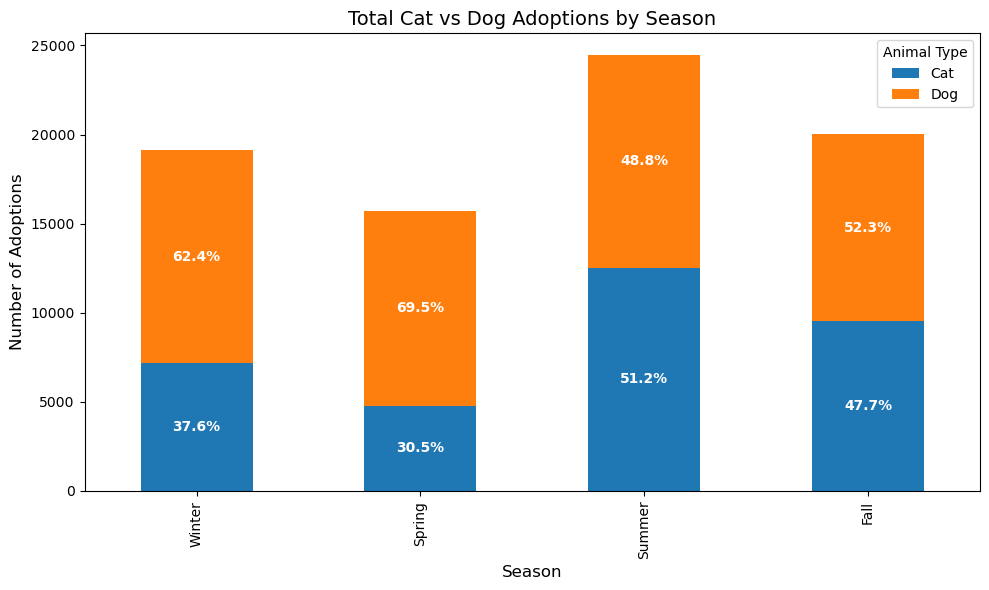

In [59]:
fig, ax = plt.subplots(figsize=(10,6))
pivot_table.plot(kind='bar', stacked=True, ax=ax)
plt.title('Total Cat vs Dog Adoptions by Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Adoptions', fontsize=12)
plt.legend(title='Animal Type')

handles, labels = ax.get_legend_handles_labels()
new_labels = ['Cat', 'Dog']
ax.legend(handles=handles, labels=new_labels, title='Animal Type')

total_adoptions = pivot_table.sum().sum()

row_totals = pivot_table.sum(axis=1).values 

for container in ax.containers:
    labels = [
        f'{(height / total) * 100:.1f}%'
        for height, total in zip(container.datavalues, row_totals)
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

I used the pivot table data to create a stacked bar chart to show total adoption by season for cats and dogs. This visualization helps identify which seasons have the highest adoption activity and if one animal was adopted more frequently.

In [60]:
crosstab = pd.crosstab(index=final_project_df['season'],
                       columns=[final_project_df['animal_type_Dog'], final_project_df['animal_type_Cat']])
display(crosstab)

animal_type_Dog,False,True
animal_type_Cat,True,False
season,,
Winter,7189,11923
Spring,4793,10931
Summer,12528,11929
Fall,9552,10462


I also wanted to implement cross-tabulation just to get a better view on other methods to clean up and properly group data.

Below, I performed a Chi-Square Goodness-of-Fit Test separately for dogs and cats to test if adoption counts vary significantly by season.

In [61]:
from scipy.stats import chisquare

dogs_by_season = pivot_table['animal_type_Dog']
observed_dogs = dogs_by_season.values

In [62]:
dogs_by_season = pivot_table['animal_type_Dog']
observed_dogs = dogs_by_season.values

expected_dogs = np.repeat(observed_dogs.sum() / len(observed_dogs),
                          len(observed_dogs))

chi2_dogs, p_dogs = chisquare(f_obs=observed_dogs, f_exp=expected_dogs)
dof_dogs = len(observed_dogs) - 1

print("Chi-square statistic:", chi2_dogs)
print("Degrees of freedom:", dof_dogs)
print(f"Scientific notation p-value: {p_dogs:.10e}")

Chi-square statistic: 143.36777544480054
Degrees of freedom: 3
Scientific notation p-value: 7.0998163447e-31


We can reject the null hypothesis due to the small p value. 
Adoption rates for dogs does significantly depend on the season. 

In [63]:
cats_by_season = pivot_table['animal_type_Cat']
observed_cats = cats_by_season.values

expected_cats = np.repeat(observed_cats.sum() / len(observed_cats),
                          len(observed_cats))

chi2_cats, p_cats = chisquare(f_obs=observed_cats, f_exp=expected_cats)
dof_cats = len(observed_cats) - 1 

print("Chi-square statistic:", chi2_cats)
print("Degrees of freedom:", dof_cats)
print(f"Scientific notation p-value: {p_cats:.10e}")

Chi-square statistic: 3850.7541541894198
Degrees of freedom: 3
Scientific notation p-value: 0.0000000000e+00


We can reject the null hypothesis due to the small p value. 
Adoption rates for cats does significantly depend on the season. 